# 06 — D7 como alerta temprana + D8 como confirmación

Objetivo: comprobar con criterios causales y fácilmente auditables si D7 (CUSUM online robusto) aporta alerta temprana y D8 (HMM t-Student de cuatro estados) aporta una confirmación sólida. La decisión tiene tres estados: **normal → vigilancia → confirmado**.

## Contrato fijado antes de evaluar

- D7 abre vigilancia al entrar en su estado de crisis (`n_states − 1`, fijado por el detector y no inferido del panel), solo si D8 todavía no confirma.
- D8 confirma cuando `p_crisis ≥ 0.50` durante 3 sesiones consecutivas.
- El aviso es válido hasta 63 sesiones después; D8 prevalece sobre vigilancia.
- Cada aviso y cada confirmación se emparejan como máximo una vez.
- Las crisis conocidas nunca intervienen en la decisión: solo se usan después para evaluarla.
- 0,50/3/63 es la configuración principal; las demás combinaciones son sensibilidad, no optimización.
- La pareja D7+D8 viene dada (no se eligió mirando estos resultados); el índice de utilidad es descriptivo y solo ordena alternativas (ver `src.fusion.operational_utility`).

In [1]:
from dataclasses import replace
import importlib
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
while not (ROOT / 'data' / 'benchmark_spec.yaml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if not (ROOT / 'data' / 'benchmark_spec.yaml').exists():
    raise FileNotFoundError('No se encontró la raíz del proyecto.')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
from IPython.display import display

from src import evaluation as ev
from src.benchmark import configure_evaluation
import src.fusion as fusion_module
importlib.reload(fusion_module)  # evita una versión antigua retenida por el kernel
from src.fusion import (
    FusionConfig, ablation_scorecard, assert_prefix_causal,
    confirmation_episode_table, crisis_state_from_metrics, fuse_early_warning,
    fusion_verdict, load_panel, per_crisis_scorecard, sensitivity_table,
    warning_episode_table, warning_ground_truth_table, warning_phase_base_rates,
    warning_summary, PHASES,
)

BENCHMARK = ROOT / 'results' / 'benchmark_v2'
OUTPUT = ROOT / 'results' / 'fusion_d07_d08'
OUTPUT.mkdir(parents=True, exist_ok=True)
CONFIG = FusionConfig(confirmation_threshold=0.50, confirmation_persistence=3, warning_horizon=63)
TRACKS = ('A', 'B')
benchmark_reference = pd.read_csv(BENCHMARK / 'metrics_master_v2.csv')
# Estado de crisis de D7 por pista = n_states - 1 (propiedad del detector, no del panel).
TRACK_CONFIG = {
    track: replace(CONFIG, alert_crisis_state=crisis_state_from_metrics(benchmark_reference, track, 'D07'))
    for track in TRACKS
}
benchmark_reference.query("id in ['D07', 'D08']")[[
    'pista', 'id', 'detector', 'label_stability', 'mean_crisis_coverage',
    'false_alarm_rate', 'puesto_pista',
]].sort_values(['pista', 'id']).set_index(['pista', 'id']).round(3)

detector  label_stability  mean_crisis_coverage  \
pista id                                                               
A     D07  changepoint_online            1.000                 0.646   
      D08     hmm_tstudent_4s            0.751                 0.370   
B     D07  changepoint_online            0.995                 0.285   
      D08     hmm_tstudent_4s            0.691                 0.054   

           false_alarm_rate  puesto_pista  
pista id                                   
A     D07             0.672           1.0  
      D08             0.674          11.0  
B     D07             0.655           5.0  
      D08             0.908          12.0

In [2]:
fused, causal_checks = {}, {}
for track in TRACKS:
    d7 = load_panel(BENCHMARK, track, 'D07')
    d8 = load_panel(BENCHMARK, track, 'D08')
    fused[track] = fuse_early_warning(d7, d8, TRACK_CONFIG[track])
    causal_checks[track] = assert_prefix_causal(d7, d8, TRACK_CONFIG[track])
pd.Series(causal_checks, name='invariante_al_truncado').to_frame()

,invariante_al_truncado
A,True
B,True


## 1. Acuerdo D7→D8, sin doble contabilización

Primero se mide si D8 coincide después con D7. Esto es **acuerdo entre detectores**, todavía no anticipación de una crisis real. Una confirmación consume el aviso elegible más reciente y ningún aviso puede explicar dos reentradas de D8.

In [3]:
summary_rows, warning_tables, confirmation_tables = [], {}, {}
for track in TRACKS:
    summary_rows.append({'pista': track, **warning_summary(fused[track], CONFIG.warning_horizon)})
    warning_tables[track] = warning_episode_table(fused[track], CONFIG.warning_horizon).assign(pista=track)
    confirmation_tables[track] = confirmation_episode_table(fused[track], CONFIG.warning_horizon).assign(pista=track)
warning_metrics = pd.DataFrame(summary_rows).set_index('pista')
display(warning_metrics.round(3))
display(pd.concat(warning_tables.values(), ignore_index=True)[[
    'pista', 'alert_date', 'confirmation_date', 'lead_sessions', 'outcome'
]])

,warnings,confirmed_warnings,false_or_unconfirmed_warnings,warning_precision,confirmation_episodes,preceded_confirmations,confirmation_recall,median_lead_sessions,share_warning_days,share_confirmed_days,decision_switching_rate,mean_decision_duration
pista,,,,,,,,,,,,
A,7.0,4.0,3.0,0.571,57.0,4.0,0.07,4.5,0.027,0.247,0.009,111.283
B,6.0,2.0,4.0,0.333,4.0,2.0,0.50,24.0,0.080,0.043,0.005,202.950


,pista,alert_date,confirmation_date,lead_sessions,outcome
0,A,1970-05-12,NaT,NaN,false_or_unconfirmed
1,A,1973-05-14,NaT,NaN,already_confirmed
2,A,1978-11-02,NaT,NaN,already_confirmed
3,A,1980-03-24,NaT,NaN,already_confirmed
4,A,1987-10-16,NaT,NaN,already_confirmed
5,A,1990-08-27,1990-09-05,6.0,confirmed
6,A,1997-10-28,1997-10-30,2.0,confirmed
7,A,2000-03-14,2000-03-17,3.0,confirmed
8,A,2007-08-09,NaT,NaN,false_or_unconfirmed
9,A,2010-05-07,NaT,NaN,false_or_unconfirmed


## 2. ¿Es realmente alerta temprana de crisis?

Cada aviso elegible se contrasta con el inicio y final de las crisis congeladas: `anticipacion`, `durante_crisis`, `posterior` o `falsa_alarma`. El adelanto positivo se mide hasta el inicio de la crisis; un valor negativo significa que el evento ya había empezado.

Para no confundir anticipación con azar se añade una **línea base**: la fracción de sesiones OOS que caería en cada fase si el aviso se emitiera en un día aleatorio (`warning_phase_base_rates`). Con 6–7 avisos por pista la comparación es orientativa, no un test.

In [4]:
ground_truth_tables = {}
for track in TRACKS:
    configure_evaluation(track)
    ground_truth_tables[track] = warning_ground_truth_table(
        fused[track], CONFIG.warning_horizon
    ).assign(pista=track)
ground_truth_warnings = pd.concat(ground_truth_tables.values(), ignore_index=True)
phase_summary = (ground_truth_warnings.groupby(['pista', 'phase']).size()
                 .unstack(fill_value=0).reindex(columns=[
                     'anticipacion', 'durante_crisis', 'posterior', 'falsa_alarma'
                 ], fill_value=0))
display(phase_summary)
baseline_rows = {}
for track in TRACKS:
    configure_evaluation(track)
    baseline_rows[track] = warning_phase_base_rates(fused[track].index, CONFIG.warning_horizon)
phase_baseline = pd.DataFrame(baseline_rows).T.rename_axis('pista').reindex(columns=list(PHASES))
phase_expected = phase_baseline.mul(phase_summary.sum(axis=1), axis=0)
display(pd.concat({'observado': phase_summary.astype(float), 'esperado_azar': phase_expected,
                   'fraccion_azar': phase_baseline}, axis=1).round(2))
display(ground_truth_warnings[[
    'pista', 'alert_date', 'confirmation_date', 'crisis', 'phase',
    'lead_to_crisis_start_sessions', 'lead_to_confirmation_sessions',
]])

phase,anticipacion,durante_crisis,posterior,falsa_alarma
pista,,,,
A,2,3,1,1
B,0,4,2,0


observado                                       esperado_azar  \
phase anticipacion durante_crisis posterior falsa_alarma  anticipacion   
pista                                                                    
A              2.0            3.0       1.0          1.0          0.49   
B              0.0            4.0       2.0          0.0          0.72   

                                            fraccion_azar                 \
phase durante_crisis posterior falsa_alarma  anticipacion durante_crisis   
pista                                                                      
A               1.36      0.52         4.64          0.07           0.19   
B               1.04      0.80         3.44          0.12           0.17   

                              
phase posterior falsa_alarma  
pista                         
A          0.07         0.66  
B          0.13         0.57

,pista,alert_date,confirmation_date,crisis,phase,lead_to_crisis_start_sessions,lead_to_confirmation_sessions
0,A,1970-05-12,NaT,bear_1969_70,durante_crisis,0.0,NaN
1,A,1990-08-27,1990-09-05,gulf_war_sl_1990,durante_crisis,-30.0,6.0
2,A,1997-10-28,1997-10-30,None,falsa_alarma,NaN,2.0
3,A,2000-03-14,2000-03-17,dotcom_2000_02,anticipacion,8.0,3.0
4,A,2007-08-09,NaT,gfc_2007_09,anticipacion,42.0,NaN
5,A,2010-05-07,NaT,flash_crash_euro1_2010,durante_crisis,-10.0,NaN
6,A,2018-02-12,2018-04-25,volmageddon_2018q1,posterior,-11.0,50.0
7,B,2011-08-11,2011-10-11,us_downgrade_euro2_2011,durante_crisis,-72.0,42.0
8,B,2015-08-27,NaT,china_oil_2015_16,durante_crisis,-68.0,NaN
9,B,2020-03-03,2020-03-11,covid_2020,durante_crisis,-9.0,6.0


## 3. Ablación: ¿qué parte aporta valor?

La arquitectura original es paralela: D8 puede confirmar sin aviso previo y D7 puede abrir vigilancia sin D8. También se prueba un embudo estricto donde solo se acepta D8 si hubo D7 antes. La utilidad descriptiva es la misma del notebook 07: `cobertura − falsas alarmas − trampas − 5×cambios` (`src.fusion.operational_utility`). Solo ordena alternativas evaluadas con las mismas labels: su signo no significa "peor que no hacer nada" (una señal siempre activa puntúa `−fracción de días fuera de crisis`).

In [5]:
ablation_rows, crisis_rows, verdict_rows = [], [], []
for track in TRACKS:
    configure_evaluation(track)
    ablation = ablation_scorecard(fused[track], CONFIG.warning_horizon).assign(pista=track)
    ablation_rows.append(ablation)
    crisis_rows.append(per_crisis_scorecard(fused[track]).assign(pista=track))
    indexed = ablation.set_index('arquitectura')
    joint, d7, d8 = indexed.loc['fusion_paralela'], indexed.loc['D7_solo'], indexed.loc['D8_solo']
    verdict_rows.append({
        'pista': track,
        'delta_utilidad_vs_D7': joint.operational_utility - d7.operational_utility,
        'delta_utilidad_vs_D8': joint.operational_utility - d8.operational_utility,
        'pareto_domina_D7': bool(joint.mean_crisis_coverage >= d7.mean_crisis_coverage and joint.false_alarm_rate <= d7.false_alarm_rate),
        'pareto_domina_D8': bool(joint.mean_crisis_coverage >= d8.mean_crisis_coverage and joint.false_alarm_rate <= d8.false_alarm_rate),
        # alerta = D7, confirmador = D8
        'veredicto': fusion_verdict(joint.operational_utility, d7.operational_utility, d8.operational_utility),
    })
ablation_table = pd.concat(ablation_rows, ignore_index=True)
scorecard = ablation_table.loc[ablation_table['arquitectura'].isin([
    'D7_solo', 'D8_solo', 'fusion_paralela'
])].copy()
scorecard['signal'] = scorecard['arquitectura'].map({
    'D7_solo': 'alerta', 'D8_solo': 'confirmacion', 'fusion_paralela': 'accionable'
})
per_crisis = pd.concat(crisis_rows, ignore_index=True)
verdict = pd.DataFrame(verdict_rows).set_index('pista')
display(ablation_table.set_index(['pista', 'arquitectura']).round(3))
display(verdict.round(3))
display(per_crisis.set_index(['pista', 'crisis']).round(3))

mean_crisis_coverage  false_alarm_rate  \
pista arquitectura                                                      
A     D7_solo                                 0.646             0.672   
      D8_solo                                 0.346             0.674   
      fusion_paralela                         0.489             0.668   
      confirmacion_D8_tras_D7                 0.002             0.692   
      fusion_secuencial                       0.145             0.638   
B     D7_solo                                 0.285             0.655   
      D8_solo                                 0.044             0.926   
      fusion_paralela                         0.184             0.632   
      confirmacion_D8_tras_D7                 0.042             0.943   
      fusion_secuencial                       0.182             0.627   

                               mean_trap_activation  switching_rate  \
pista arquitectura                                                    
A     D7_solo                                 0.000           0.002   
      D8_solo                                 0.000           0.008   
      fusion_paralela                         0.000           0.008   
      confirmacion_D8_tras_D7                 0.000           0.001   
      fusion_secuencial                       0.000           0.001   
B     D7_solo                                 0.000           0.003   
      D8_solo                                 0.068           0.002   
      fusion_paralela                         0.068           0.004   
      confirmacion_D8_tras_D7                 0.000           0.001   
      fusion_secuencial                       0.000           0.003   

                               mean_duration  operational_utility  
pista arquitectura                                                 
A     D7_solo                        441.656               -0.037  
      D8_solo                        122.896               -0.369  
      fusion_paralela                119.771               -0.220  
      confirmacion_D8_tras_D7       1570.333               -0.693  
      fusion_secuencial             1009.500               -0.497  
B     D7_solo                        312.231               -0.385  
      D8_solo                        451.000               -0.960  
      fusion_paralela                238.765               -0.536  
      confirmacion_D8_tras_D7        811.800               -0.906  
      fusion_secuencial              312.231               -0.459

,delta_utilidad_vs_D7,delta_utilidad_vs_D8,pareto_domina_D7,pareto_domina_D8,veredicto
pista,,,,,
A,-0.183,0.149,False,True,mejora_confirmador_pero_no_alerta
B,-0.151,0.424,False,True,mejora_confirmador_pero_no_alerta


D7_alerta  D8_confirmacion  fusion_paralela
pista crisis                                                              
A     credit_crunch_1966             NaN              NaN              NaN
      bear_1969_70                 1.000            0.000            1.000
      oil_stagflation_1973         0.808            0.378            0.378
      volcker_1980_82              1.000            0.334            0.334
      black_monday_1987            0.486            0.653            0.653
      gulf_war_sl_1990             0.524            0.016            0.524
      ltcm_russia_1998             1.000            0.031            0.031
      dotcom_2000_02               1.000            0.339            0.409
      gfc_2007_09                  1.000            0.593            0.654
      flash_crash_euro1_2010       0.800            0.000            0.800
      us_downgrade_euro2_2011      0.349            0.358            0.358
      china_oil_2015_16            0.353            0.304            0.304
      volmageddon_2018q1           0.000            0.000            0.000
      fed_tightening_2018q4        0.000            0.652            0.652
      covid_2020                   0.667            0.792            0.792
      inflation_bear_2022          1.000            0.888            0.888
      svb_banking_2023             1.000            0.000            0.000
      tariff_selloff_2025          0.000            0.543            0.543
B     gfc_2007_09                    NaN              NaN              NaN
      flash_crash_euro1_2010       0.000            0.000            0.000
      us_downgrade_euro2_2011      0.174            0.000            0.339
      china_oil_2015_16            0.348            0.000            0.348
      volmageddon_2018q1           0.000            0.000            0.000
      fed_tightening_2018q4        0.000            0.000            0.000
      covid_2020                   0.625            0.375            0.625
      inflation_bear_2022          0.418            0.020            0.347
      svb_banking_2023             1.000            0.000            0.000
      tariff_selloff_2025          0.000            0.000            0.000

## 4. Incertidumbre por evento

Los días de una crisis están autocorrelacionados; no se remuestrean como observaciones independientes. Se remuestrean crisis completas 5.000 veces y se muestra también el rango *leave-one-crisis-out*. Un intervalo que cruza cero significa que la diferencia de cobertura no es robusta al pequeño número de eventos.

In [6]:
def event_uncertainty(values, seed, n_boot=5000):
    values = np.asarray(pd.Series(values).dropna(), dtype=float)
    rng = np.random.default_rng(seed)
    bootstrap = rng.choice(values, size=(n_boot, len(values)), replace=True).mean(axis=1)
    loo = np.array([np.delete(values, i).mean() for i in range(len(values))]) if len(values) > 1 else np.array([np.nan])
    return {
        'n_crisis': len(values), 'diferencia_media': values.mean(),
        'bootstrap_lo_95': np.quantile(bootstrap, 0.025),
        'bootstrap_hi_95': np.quantile(bootstrap, 0.975),
        'loo_min': np.nanmin(loo), 'loo_max': np.nanmax(loo),
    }

uncertainty_rows = []
for track_number, track in enumerate(TRACKS):
    part = per_crisis.query('pista == @track')
    for baseline in ('D7_alerta', 'D8_confirmacion'):
        difference = part['fusion_paralela'] - part[baseline]
        uncertainty_rows.append({
            'pista': track, 'comparacion': f'fusion_menos_{baseline}',
            **event_uncertainty(difference, seed=20260830 + track_number),
        })
uncertainty = pd.DataFrame(uncertainty_rows)
uncertainty.set_index(['pista', 'comparacion']).round(3)

n_crisis  diferencia_media  \
pista comparacion                                                
A     fusion_menos_D7_alerta              17            -0.157   
      fusion_menos_D8_confirmacion        17             0.144   
B     fusion_menos_D7_alerta               9            -0.101   
      fusion_menos_D8_confirmacion         9             0.140   

                                    bootstrap_lo_95  bootstrap_hi_95  loo_min  \
pista comparacion                                                               
A     fusion_menos_D7_alerta                 -0.363            0.053   -0.207   
      fusion_menos_D8_confirmacion            0.012            0.304    0.090   
B     fusion_menos_D7_alerta                 -0.341            0.047   -0.134   
      fusion_menos_D8_confirmacion            0.038            0.244    0.114   

                                    loo_max  
pista comparacion                            
A     fusion_menos_D7_alerta         -0.104  
      fusion_menos_D8_confirmacion    0.153  
B     fusion_menos_D7_alerta          0.012  
      fusion_menos_D8_confirmacion    0.158

## 5. Robustez de horizonte, umbral y persistencia

Se mantiene 63/0,50/3 como caso principal. La cuadrícula no elige el mejor resultado: comprueba si la conclusión depende de una parametrización muy concreta de D8.

In [7]:
sensitivity_rows = []
for track in TRACKS:
    configure_evaluation(track)
    sensitivity_rows.append(sensitivity_table(
        load_panel(BENCHMARK, track, 'D07'), load_panel(BENCHMARK, track, 'D08'),
        TRACK_CONFIG[track], horizons=(21, 63, 126),
    ).assign(pista=track))
sensitivity = pd.concat(sensitivity_rows, ignore_index=True)
display(sensitivity.set_index(['pista', 'warning_horizon'])[[
    'warnings', 'warning_precision', 'confirmation_recall', 'median_lead_sessions',
    'actionable_crisis_coverage', 'actionable_false_alarm_rate',
]].round(3))

warnings  warning_precision  confirmation_recall  \
pista warning_horizon                                                     
A     21                    7.0              0.429                0.053   
      63                    7.0              0.571                0.070   
      126                   7.0              0.714                0.088   
B     21                    6.0              0.167                0.250   
      63                    6.0              0.333                0.500   
      126                   6.0              0.333                0.500   

                       median_lead_sessions  actionable_crisis_coverage  \
pista warning_horizon                                                     
A     21                                3.0                       0.450   
      63                                4.5                       0.489   
      126                               6.0                       0.498   
B     21                                6.0                       0.120   
      63                               24.0                       0.184   
      126                              24.0                       0.337   

                       actionable_false_alarm_rate  
pista warning_horizon                               
A     21                                     0.669  
      63                                     0.668  
      126                                    0.678  
B     21                                     0.708  
      63                                     0.632  
      126                                    0.638

In [8]:
robustness_rows = []
for track in TRACKS:
    d7, d8 = load_panel(BENCHMARK, track, 'D07'), load_panel(BENCHMARK, track, 'D08')
    for threshold in (0.40, 0.50, 0.60):
        for persistence in (1, 3, 5):
            config = replace(TRACK_CONFIG[track], confirmation_threshold=threshold, confirmation_persistence=persistence)
            frame = fuse_early_warning(d7, d8, config)
            configure_evaluation(track)
            ablation = ablation_scorecard(frame, config.warning_horizon).set_index('arquitectura')
            joint, d7_only, d8_only = ablation.loc['fusion_paralela'], ablation.loc['D7_solo'], ablation.loc['D8_solo']
            robustness_rows.append({
                'pista': track, 'umbral_D8': threshold, 'persistencia_D8': persistence,
                'configuracion_principal': threshold == CONFIG.confirmation_threshold and persistence == CONFIG.confirmation_persistence,
                'cobertura_fusion': joint.mean_crisis_coverage, 'FA_fusion': joint.false_alarm_rate,
                'utilidad_fusion': joint.operational_utility,
                'delta_utilidad_vs_D7': joint.operational_utility - d7_only.operational_utility,
                'delta_utilidad_vs_D8': joint.operational_utility - d8_only.operational_utility,
            })
robustness = pd.DataFrame(robustness_rows)
display(robustness.set_index(['pista', 'umbral_D8', 'persistencia_D8']).round(3))
robustness_summary = robustness.groupby('pista').agg(
    casos=('utilidad_fusion', 'size'),
    mejora_D7=('delta_utilidad_vs_D7', lambda x: int((x > 0).sum())),
    mejora_D8=('delta_utilidad_vs_D8', lambda x: int((x > 0).sum())),
    utilidad_min=('utilidad_fusion', 'min'), utilidad_max=('utilidad_fusion', 'max'),
)
robustness_summary.round(3)

configuracion_principal  cobertura_fusion  \
pista umbral_D8 persistencia_D8                                              
A     0.4       1                                  False             0.511   
                3                                  False             0.494   
                5                                  False             0.484   
      0.5       1                                  False             0.512   
                3                                   True             0.489   
                5                                  False             0.478   
      0.6       1                                  False             0.509   
                3                                  False             0.486   
                5                                  False             0.475   
B     0.4       1                                  False             0.185   
                3                                  False             0.184   
                5                                  False             0.183   
      0.5       1                                  False             0.185   
                3                                   True             0.184   
                5                                  False             0.183   
      0.6       1                                  False             0.185   
                3                                  False             0.184   
                5                                  False             0.183   

                                 FA_fusion  utilidad_fusion  \
pista umbral_D8 persistencia_D8                               
A     0.4       1                    0.672           -0.207   
                3                    0.668           -0.214   
                5                    0.664           -0.219   
      0.5       1                    0.664           -0.198   
                3                    0.668           -0.220   
                5                    0.664           -0.225   
      0.6       1                    0.664           -0.202   
                3                    0.668           -0.224   
                5                    0.664           -0.229   
B     0.4       1                    0.632           -0.548   
                3                    0.632           -0.536   
                5                    0.633           -0.527   
      0.5       1                    0.632           -0.548   
                3                    0.632           -0.536   
                5                    0.633           -0.527   
      0.6       1                    0.634           -0.550   
                3                    0.633           -0.538   
                5                    0.634           -0.529   

                                 delta_utilidad_vs_D7  delta_utilidad_vs_D8  
pista umbral_D8 persistencia_D8                                              
A     0.4       1                              -0.171                 0.137  
                3                              -0.178                 0.147  
                5                              -0.182                 0.163  
      0.5       1                              -0.161                 0.151  
                3                              -0.183                 0.149  
                5                              -0.189                 0.163  
      0.6       1                              -0.166                 0.151  
                3                              -0.188                 0.149  
                5                              -0.193                 0.164  
B     0.4       1                              -0.163                 0.397  
                3                              -0.151                 0.424  
                5                              -0.143                 0.453  
      0.5       1                              -0.163                 0.397  
                3                        

,casos,mejora_D7,mejora_D8,utilidad_min,utilidad_max
pista,,,,,
A,9,0,9,-0.229,-0.198
B,9,0,9,-0.550,-0.527


## 6. Prueba económica ilustrativa

No es una estrategia optimizada. Se traduce la señal a exposición al S&P 500: normal 100%, vigilancia 50% y confirmado 0%. La exposición se retrasa una sesión y se cobran 10 puntos básicos por unidad de rotación. Se compara con buy-and-hold y con apagar exposición usando D7 o D8 por separado.

rentabilidad_anual  volatilidad_anual  sharpe_rf0  \
pista politica                                                              
A     buy_and_hold                   0.085              0.172       0.494   
      D7_solo                        0.051              0.092       0.555   
      D8_solo                        0.063              0.122       0.518   
      fusion_3_estados               0.063              0.118       0.535   
B     buy_and_hold                   0.122              0.173       0.703   
      D7_solo                        0.078              0.140       0.559   
      D8_solo                        0.105              0.156       0.670   
      fusion_3_estados               0.092              0.145       0.635   

                        max_drawdown  retorno_medio_crisis  rotacion_anual  \
pista politica                                                               
A     buy_and_hold            -0.568                -0.250           0.000   
      D7_solo                 -0.246                -0.083           0.571   
      D8_solo                 -0.334                -0.133           2.033   
      fusion_3_estados        -0.349                -0.124           2.068   
B     buy_and_hold            -0.339                -0.178           0.000   
      D7_solo                 -0.255                -0.150           0.745   
      D8_solo                 -0.247                -0.161           0.497   
      fusion_3_estados        -0.269                -0.158           0.745   

                        exposicion_media  
pista politica                            
A     buy_and_hold                 1.000  
      D7_solo                      0.510  
      D8_solo                      0.753  
      fusion_3_estados             0.740  
B     buy_and_hold                 1.000  
      D7_solo                      0.852  
      D8_solo                      0.957  
      fusion_3_estados             0.917

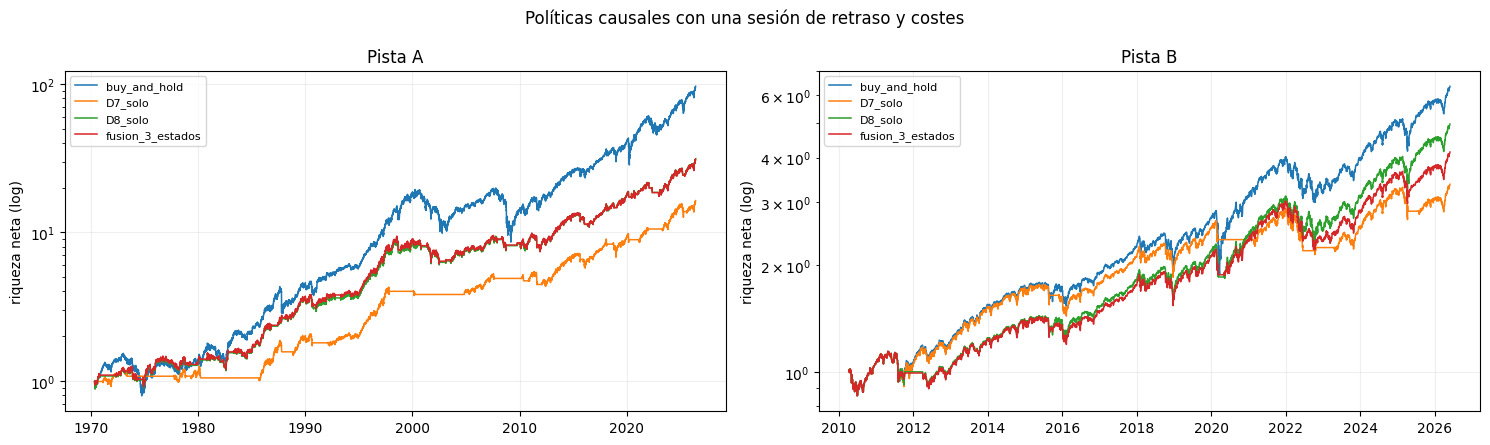

In [9]:
sp500_price = pd.read_parquet(ROOT / 'data' / 'raw' / 'yfinance' / 'SP500.parquet')['SP500'].sort_index()
sp500_return = sp500_price.pct_change(fill_method=None)

def policy_result(name, target_exposure, market_return, cost=0.001):
    aligned_return = market_return.reindex(target_exposure.index).fillna(0.0)
    applied = target_exposure.shift(1).fillna(1.0).astype(float)
    turnover = applied.diff().abs().fillna(0.0)
    net = applied * aligned_return - cost * turnover
    wealth = (1.0 + net).cumprod()
    years = len(net) / 252.0
    drawdown = wealth / wealth.cummax() - 1.0
    crisis_returns = []
    for start, end in ev.CRISIS_WINDOWS.values():
        segment = net.loc[(net.index >= pd.Timestamp(start)) & (net.index <= pd.Timestamp(end))]
        if len(segment):
            crisis_returns.append((1.0 + segment).prod() - 1.0)
    annual_return = wealth.iloc[-1] ** (1.0 / years) - 1.0
    annual_vol = net.std(ddof=1) * np.sqrt(252.0)
    return {
        'politica': name, 'rentabilidad_anual': annual_return,
        'volatilidad_anual': annual_vol,
        'sharpe_rf0': annual_return / annual_vol if annual_vol else np.nan,
        'max_drawdown': drawdown.min(),
        'retorno_medio_crisis': np.mean(crisis_returns),
        'rotacion_anual': turnover.sum() / years,
        'exposicion_media': applied.mean(),
    }, wealth

economic_rows, wealth_curves = [], {}
for track in TRACKS:
    configure_evaluation(track)
    frame = fused[track]
    policies = {
        'buy_and_hold': pd.Series(1.0, index=frame.index),
        'D7_solo': (~frame['alert_active']).astype(float),
        'D8_solo': (~frame['confirmation_active']).astype(float),
        'fusion_3_estados': frame['decision_code'].map({0: 1.0, 1: 0.5, 2: 0.0}).astype(float),
    }
    for name, exposure in policies.items():
        row, wealth = policy_result(name, exposure, sp500_return)
        economic_rows.append({'pista': track, **row})
        wealth_curves[(track, name)] = wealth
economic_test = pd.DataFrame(economic_rows)
display(economic_test.set_index(['pista', 'politica']).round(3))

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
for ax, track in zip(axes, TRACKS):
    for name in ('buy_and_hold', 'D7_solo', 'D8_solo', 'fusion_3_estados'):
        ax.plot(wealth_curves[(track, name)].index, wealth_curves[(track, name)], label=name, lw=1.1)
    ax.set_yscale('log'); ax.set_title(f'Pista {track}'); ax.set_ylabel('riqueza neta (log)')
    ax.grid(alpha=0.2); ax.legend(fontsize=8)
fig.suptitle('Políticas causales con una sesión de retraso y costes')
fig.tight_layout(); plt.show()

## 7. Lectura visual y ampliación de episodios

Los triángulos marcan avisos elegibles D7 y las cruces, entradas de D8. Las franjas grises son crisis conocidas; azul/ámbar/rojo representan normal, vigilancia y confirmado.

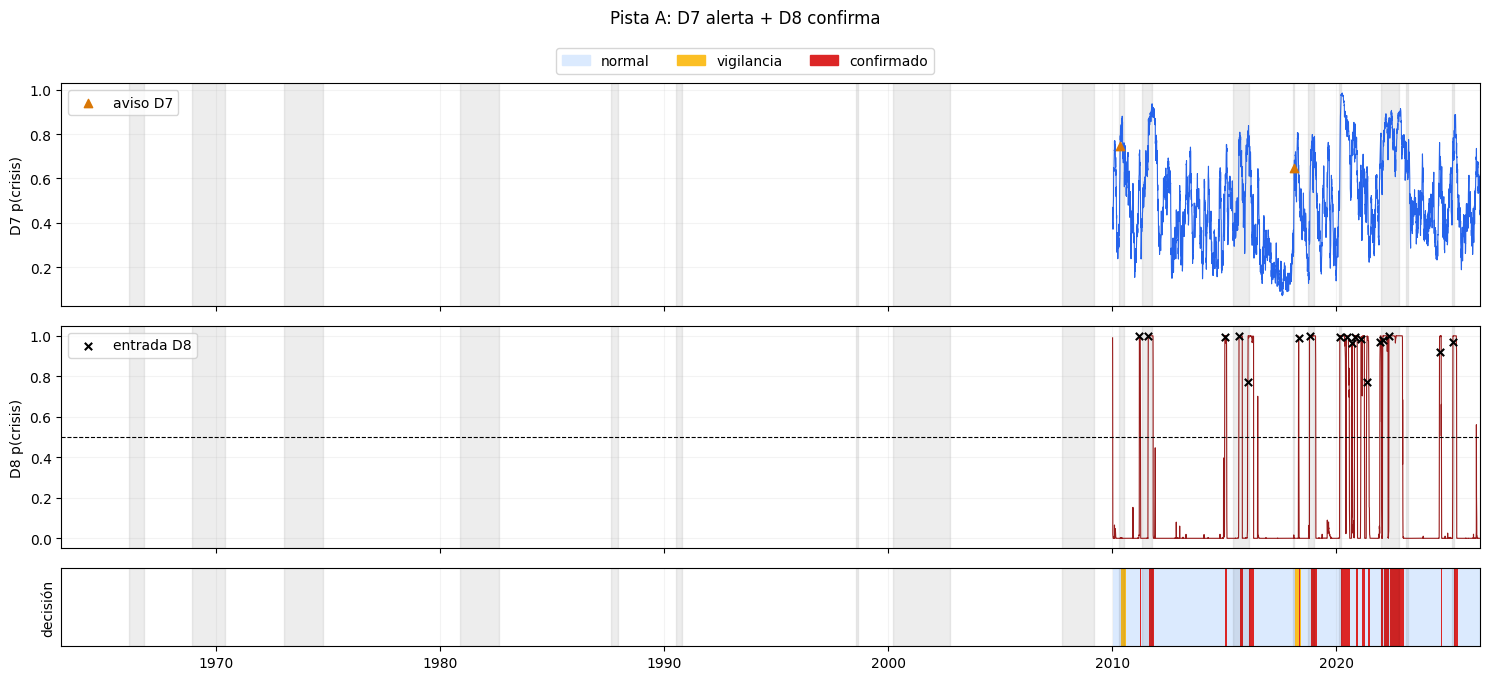

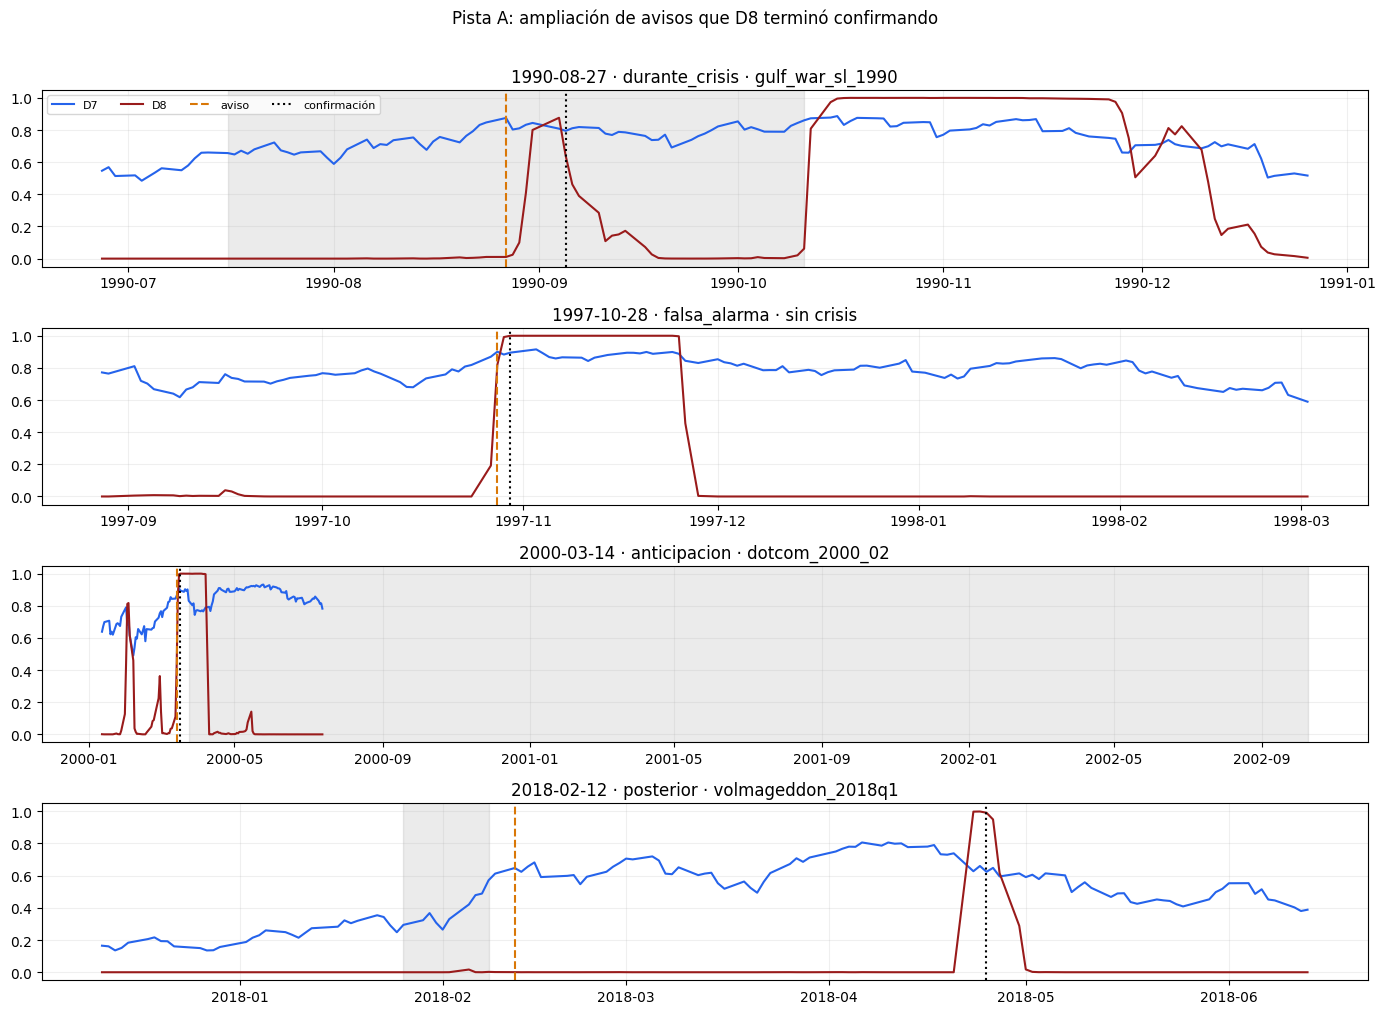

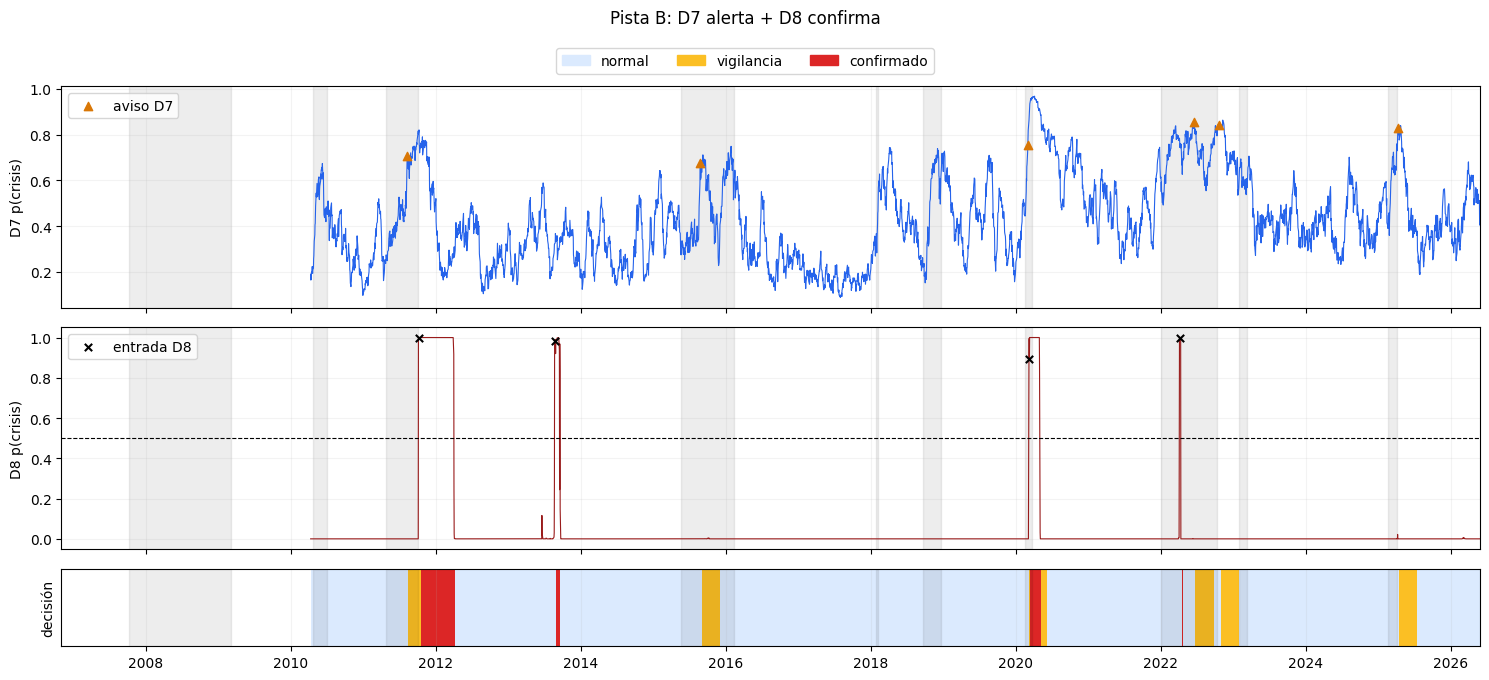

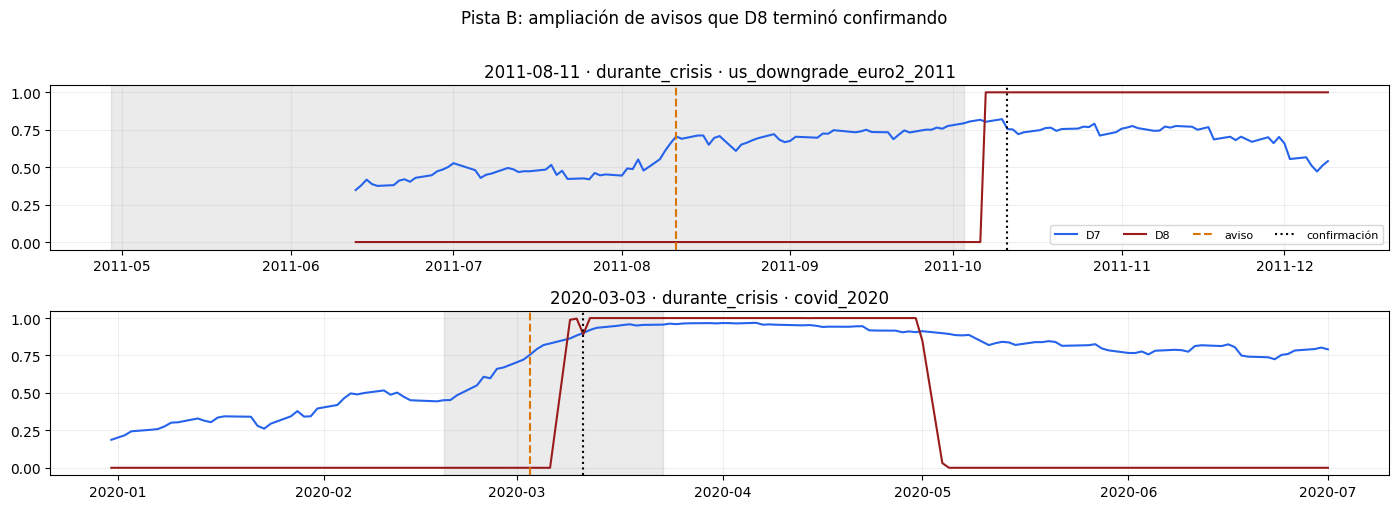

In [10]:
STATE_COLORS = ListedColormap(['#dbeafe', '#fbbf24', '#dc2626'])

def add_crises(ax):
    for start, end in ev.CRISIS_WINDOWS.values():
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), color='black', alpha=0.07)

def plot_fusion(track, frame):
    configure_evaluation(track)
    view = frame.loc[frame.index >= pd.Timestamp('2010-01-01')]
    fig, axes = plt.subplots(3, 1, figsize=(15, 6.5), sharex=True, gridspec_kw={'height_ratios': [2, 2, 0.7]})
    axes[0].plot(view.index, view['alert_probability'], color='#2563eb', lw=0.8)
    warning_dates = view.index[view['warning_onset']]
    axes[0].scatter(warning_dates, view.loc[warning_dates, 'alert_probability'], marker='^', color='#d97706', s=36, zorder=4, label='aviso D7')
    axes[0].set_ylabel('D7 p(crisis)'); axes[0].legend(loc='upper left')
    axes[1].plot(view.index, view['confirmation_probability'], color='#991b1b', lw=0.8)
    confirmation_dates = view.index[view['confirmation_onset']]
    axes[1].scatter(confirmation_dates, view.loc[confirmation_dates, 'confirmation_probability'], marker='x', color='black', s=28, zorder=4, label='entrada D8')
    axes[1].axhline(CONFIG.confirmation_threshold, color='black', ls='--', lw=0.8)
    axes[1].set_ylabel('D8 p(crisis)'); axes[1].legend(loc='upper left')
    axes[2].imshow(view['decision_code'].to_numpy()[None, :], aspect='auto', interpolation='nearest', cmap=STATE_COLORS, vmin=0, vmax=2, extent=[mdates.date2num(view.index[0]), mdates.date2num(view.index[-1]), 0, 1])
    axes[2].set_yticks([]); axes[2].set_ylabel('decisión'); axes[2].xaxis_date()
    for ax in axes:
        add_crises(ax); ax.grid(alpha=0.15)
    fig.legend(handles=[Patch(color='#dbeafe', label='normal'), Patch(color='#fbbf24', label='vigilancia'), Patch(color='#dc2626', label='confirmado')], loc='upper center', ncol=3, bbox_to_anchor=(0.5, 0.99))
    fig.suptitle(f'Pista {track}: D7 alerta + D8 confirma', y=1.04)
    fig.tight_layout(); plt.show()

def plot_confirmed_zooms(track, frame):
    episodes = ground_truth_tables[track].dropna(subset=['confirmation_date'])
    episodes = episodes.loc[episodes['alert_date'] >= pd.Timestamp('1990-01-01')].head(6)
    if episodes.empty:
        return
    fig, axes = plt.subplots(len(episodes), 1, figsize=(14, 2.5 * len(episodes)), squeeze=False)
    for ax, episode in zip(axes[:, 0], episodes.itertuples(index=False)):
        center = frame.index.get_indexer([episode.alert_date])[0]
        view = frame.iloc[max(0, center - 42):min(len(frame), center + 85)]
        ax.plot(view.index, view['alert_probability'], label='D7', color='#2563eb')
        ax.plot(view.index, view['confirmation_probability'], label='D8', color='#991b1b')
        ax.axvline(episode.alert_date, color='#d97706', ls='--', label='aviso')
        ax.axvline(episode.confirmation_date, color='black', ls=':', label='confirmación')
        if pd.notna(episode.crisis_start):
            ax.axvspan(episode.crisis_start, episode.crisis_end, color='black', alpha=0.08)
        ax.set_title(f'{episode.alert_date.date()} · {episode.phase} · {episode.crisis or "sin crisis"}')
        ax.grid(alpha=0.2)
    axes[0, 0].legend(ncol=4, fontsize=8)
    fig.suptitle(f'Pista {track}: ampliación de avisos que D8 terminó confirmando', y=1.01)
    fig.tight_layout(); plt.show()

for track in TRACKS:
    plot_fusion(track, fused[track])
    plot_confirmed_zooms(track, fused[track])

## Conclusión

La lectura correcta es más exigente que la versión inicial: **D7+D8 mejora claramente a D8 aislado, pero no mejora a D7 aislado** en utilidad operativa (veredicto `mejora_confirmador_pero_no_alerta` en ambas pistas; Δ utilidad frente a D7 = −0,18 en A y −0,15 en B). El intervalo por crisis de la diferencia de cobertura fusión−D7 cruza cero en ambas pistas, mientras que la mejora frente a D8 es positiva en todo el bootstrap por eventos.

El acuerdo D7→D8 no equivale a anticipación: en A solo 2 de 7 avisos preceden al comienzo de una crisis y en B ninguno (los 6 son reactivos o posteriores). Frente a la línea base de azar (avisos en fechas aleatorias), los 2 de A superan los ~0,5 esperados, pero con 7 avisos no es evidencia sólida; en B se esperaban ~0,7 y hubo 0. El embudo secuencial pierde demasiada cobertura y ninguna de las 9 variantes de umbral/persistencia de D8 hace que la fusión supere a D7.

La prueba económica tampoco muestra dominancia de la fusión: en A todas las políticas mejoran ligeramente el Sharpe de buy-and-hold y D7 solo obtiene el mejor Sharpe y el menor drawdown; en B ninguna supera el Sharpe de buy-and-hold (0,70) y la fusión queda entre D7 y D8. Es una prueba ilustrativa (un solo esquema de exposición, sin optimizar), no una validación pseudolive.


In [11]:
warning_metrics.to_csv(OUTPUT / 'warning_summary.csv')
pd.concat(warning_tables.values(), ignore_index=True).to_csv(OUTPUT / 'warning_episodes.csv', index=False)
pd.concat(confirmation_tables.values(), ignore_index=True).to_csv(OUTPUT / 'confirmation_episodes.csv', index=False)
ground_truth_warnings.to_csv(OUTPUT / 'warning_ground_truth.csv', index=False)
phase_summary.to_csv(OUTPUT / 'warning_phase_summary.csv')
phase_baseline.to_csv(OUTPUT / 'warning_phase_baseline.csv')
ablation_table.to_csv(OUTPUT / 'ablation_scorecard.csv', index=False)
scorecard[['signal', 'mean_crisis_coverage', 'false_alarm_rate', 'mean_trap_activation', 'switching_rate', 'mean_duration', 'pista']].to_csv(OUTPUT / 'event_scorecard.csv', index=False)
per_crisis.to_csv(OUTPUT / 'per_crisis_scorecard.csv', index=False)
verdict.to_csv(OUTPUT / 'verdict.csv')
uncertainty.to_csv(OUTPUT / 'event_uncertainty.csv', index=False)
sensitivity.to_csv(OUTPUT / 'sensitivity.csv', index=False)
robustness.to_csv(OUTPUT / 'd8_robustness.csv', index=False)
robustness_summary.to_csv(OUTPUT / 'd8_robustness_summary.csv')
economic_test.to_csv(OUTPUT / 'economic_policy_test.csv', index=False)
sorted(path.name for path in OUTPUT.glob('*.csv'))

['ablation_scorecard.csv',
 'confirmation_episodes.csv',
 'd8_robustness.csv',
 'd8_robustness_summary.csv',
 'economic_policy_test.csv',
 'event_scorecard.csv',
 'event_uncertainty.csv',
 'per_crisis_scorecard.csv',
 'sensitivity.csv',
 'verdict.csv',
 'warning_episodes.csv',
 'warning_ground_truth.csv',
 'warning_phase_baseline.csv',
 'warning_phase_summary.csv',
 'warning_summary.csv']